# Global EV Market Dashboard - Data Analysis

This notebook explores the Global Electric Vehicle Market (2026) dataset, checks data quality, and produces a cleaned CSV used by the Streamlit dashboard (`app.py`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('global_ev_market_charging_infrastructure_2026.csv')
df.head()

,record_id,country,region,ev_brand,vehicle_type,ev_sales_units,battery_capacity_kwh,vehicle_range_km,charging_time_hours,charging_stations,avg_ev_price_usd,energy_consumption_kwh,govt_incentives,market_adoption_rate,co2_reduction_mt,year
0,EV0001,China,Asia,Mercedes,Bus,459155,42,285,1.21,127224,77023,17.7,Yes,32.9,255.9,2026
1,EV0002,Canada,North America,Hyundai,Car,722074,50,330,0.52,112274,69502,23.3,Yes,60.1,155.1,2026
2,EV0003,Australia,Oceania,Ford,Bus,241638,105,483,2.41,76749,33908,14.0,Yes,27.7,161.6,2026
3,EV0004,China,Asia,Toyota,Car,681021,116,472,1.53,64238,57502,17.5,Yes,40.1,246.3,2026
4,EV0005,Canada,North America,Ford,SUV,714686,114,485,2.07,135149,58145,16.1,No,54.5,21.2,2026


## 1. Basic structure

In [2]:
print('Shape:', df.shape)
df.info()

Shape: (5000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               5000 non-null   str    
 1   country                 5000 non-null   str    
 2   region                  5000 non-null   str    
 3   ev_brand                5000 non-null   str    
 4   vehicle_type            5000 non-null   str    
 5   ev_sales_units          5000 non-null   int64  
 6   battery_capacity_kwh    5000 non-null   int64  
 7   vehicle_range_km        5000 non-null   int64  
 8   charging_time_hours     5000 non-null   float64
 9   charging_stations       5000 non-null   int64  
 10  avg_ev_price_usd        5000 non-null   int64  
 11  energy_consumption_kwh  5000 non-null   float64
 12  govt_incentives         5000 non-null   str    
 13  market_adoption_rate    5000 non-null   float64
 14  co2_reduction_mt        5000 non-

In [3]:
df.describe()

,ev_sales_units,battery_capacity_kwh,vehicle_range_km,charging_time_hours,charging_stations,avg_ev_price_usd,energy_consumption_kwh,market_adoption_rate,co2_reduction_mt,year
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0
mean,450391.774000,79.753800,450.278000,1.742614,100851.553400,55633.191800,18.527740,34.848660,153.196280,2026.0
std,258494.794603,23.474791,116.325407,0.719029,56905.671677,17289.560508,3.749015,17.276752,84.829245,0.0
min,5142.000000,40.000000,250.000000,0.500000,574.000000,25000.000000,12.000000,5.000000,5.100000,2026.0
25%,224814.000000,59.000000,349.000000,1.120000,52215.500000,40567.750000,15.300000,19.800000,80.000000,2026.0
50%,455096.500000,79.000000,451.000000,1.730000,100946.000000,56057.000000,18.450000,34.800000,152.850000,2026.0
75%,673542.000000,100.000000,550.000000,2.360000,149655.250000,70821.500000,21.800000,49.600000,228.425000,2026.0
max,899978.000000,120.000000,650.000000,3.000000,199969.000000,84999.000000,25.000000,65.000000,300.000000,2026.0


## 2. Data quality checks

In [4]:
# missing values
df.isnull().sum()

record_id                 0
country                   0
region                    0
ev_brand                  0
vehicle_type              0
ev_sales_units            0
battery_capacity_kwh      0
vehicle_range_km          0
charging_time_hours       0
charging_stations         0
avg_ev_price_usd          0
energy_consumption_kwh    0
govt_incentives           0
market_adoption_rate      0
co2_reduction_mt          0
year                      0
dtype: int64

In [5]:
# duplicate rows and duplicate ids
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate record_id:', df['record_id'].duplicated().sum())

Duplicate rows: 0
Duplicate record_id: 0


In [6]:
# check categorical columns for whitespace or casing inconsistencies
text_cols = ['country', 'region', 'ev_brand', 'vehicle_type', 'govt_incentives']
for col in text_cols:
    print(col, '->', sorted(df[col].unique()))

country -> ['Australia', 'Canada', 'China', 'France', 'Germany', 'India', 'Japan', 'Norway', 'United Kingdom', 'United States']
region -> ['Asia', 'Europe', 'North America', 'Oceania']
ev_brand -> ['BMW', 'BYD', 'Ford', 'Hyundai', 'Kia', 'Mercedes', 'Nissan', 'Tesla', 'Toyota', 'Volkswagen']
vehicle_type -> ['Bus', 'Car', 'SUV', 'Truck']
govt_incentives -> ['No', 'Yes']


In [7]:
# check year column - dataset only covers a single year
print('Year values:', df['year'].unique())

Year values: [2026]


The dataset only contains records for `year = 2026`, so there is no multi-year trend to plot. The dashboard substitutes a 'sales by region' view in place of a yearly trend chart.

## 3. Cleaning

In [8]:
clean_df = df.copy()

# strip whitespace from text columns just in case, and standardize column order
for col in text_cols:
    clean_df[col] = clean_df[col].str.strip()

# round float columns to 2 decimal places for consistent display
float_cols = ['charging_time_hours', 'energy_consumption_kwh', 'market_adoption_rate', 'co2_reduction_mt']
clean_df[float_cols] = clean_df[float_cols].round(2)

# reorder columns logically
column_order = [
    'record_id', 'year', 'country', 'region', 'ev_brand', 'vehicle_type',
    'ev_sales_units', 'avg_ev_price_usd', 'battery_capacity_kwh', 'vehicle_range_km',
    'energy_consumption_kwh', 'charging_time_hours', 'charging_stations',
    'govt_incentives', 'market_adoption_rate', 'co2_reduction_mt'
]
clean_df = clean_df[column_order]
clean_df.head()

,record_id,year,country,region,ev_brand,vehicle_type,ev_sales_units,avg_ev_price_usd,battery_capacity_kwh,vehicle_range_km,energy_consumption_kwh,charging_time_hours,charging_stations,govt_incentives,market_adoption_rate,co2_reduction_mt
0,EV0001,2026,China,Asia,Mercedes,Bus,459155,77023,42,285,17.7,1.21,127224,Yes,32.9,255.9
1,EV0002,2026,Canada,North America,Hyundai,Car,722074,69502,50,330,23.3,0.52,112274,Yes,60.1,155.1
2,EV0003,2026,Australia,Oceania,Ford,Bus,241638,33908,105,483,14.0,2.41,76749,Yes,27.7,161.6
3,EV0004,2026,China,Asia,Toyota,Car,681021,57502,116,472,17.5,1.53,64238,Yes,40.1,246.3
4,EV0005,2026,Canada,North America,Ford,SUV,714686,58145,114,485,16.1,2.07,135149,No,54.5,21.2


In [9]:
clean_df.to_csv('global_ev_market_cleaned.csv', index=False)
print('Saved cleaned CSV with shape', clean_df.shape)

Saved cleaned CSV with shape (5000, 16)


## 4. Exploratory analysis

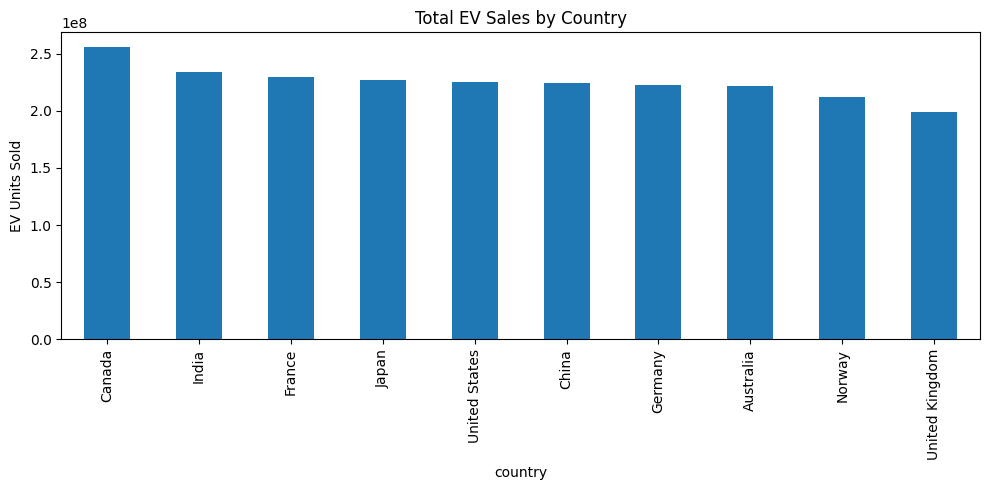

In [10]:
sales_by_country = clean_df.groupby('country')['ev_sales_units'].sum().sort_values(ascending=False)
sales_by_country.plot(kind='bar', figsize=(10,5), title='Total EV Sales by Country')
plt.ylabel('EV Units Sold')
plt.tight_layout()
plt.show()

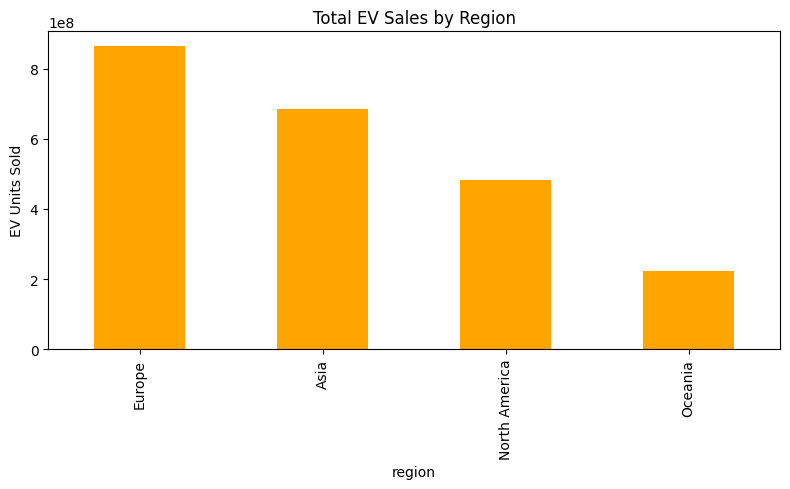

In [11]:
sales_by_region = clean_df.groupby('region')['ev_sales_units'].sum().sort_values(ascending=False)
sales_by_region.plot(kind='bar', figsize=(8,5), title='Total EV Sales by Region', color='orange')
plt.ylabel('EV Units Sold')
plt.tight_layout()
plt.show()

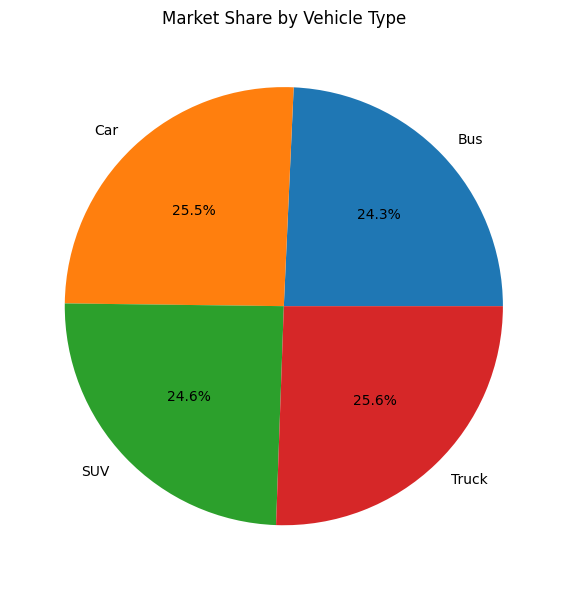

In [12]:
market_share = clean_df.groupby('vehicle_type')['ev_sales_units'].sum()
market_share.plot(kind='pie', figsize=(6,6), autopct='%1.1f%%', title='Market Share by Vehicle Type')
plt.ylabel('')
plt.tight_layout()
plt.show()

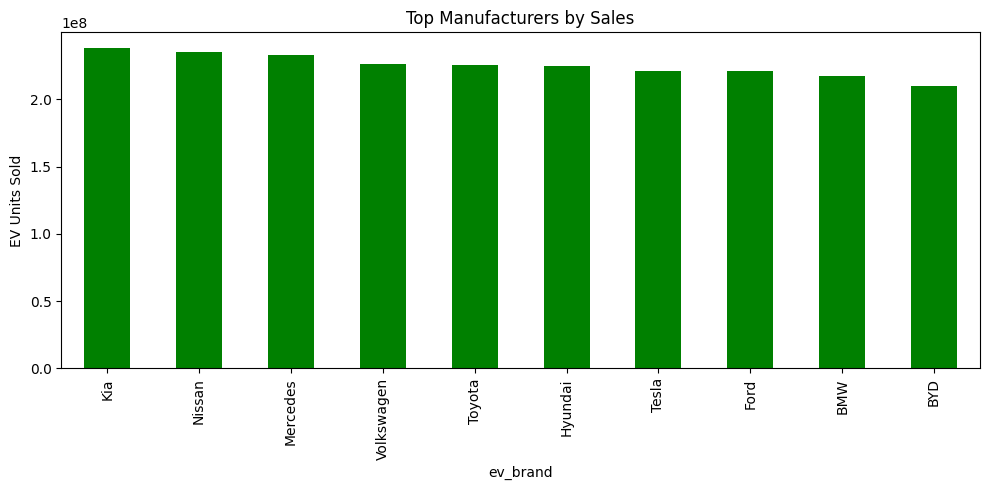

In [13]:
top_brands = clean_df.groupby('ev_brand')['ev_sales_units'].sum().sort_values(ascending=False)
top_brands.plot(kind='bar', figsize=(10,5), title='Top Manufacturers by Sales', color='green')
plt.ylabel('EV Units Sold')
plt.tight_layout()
plt.show()

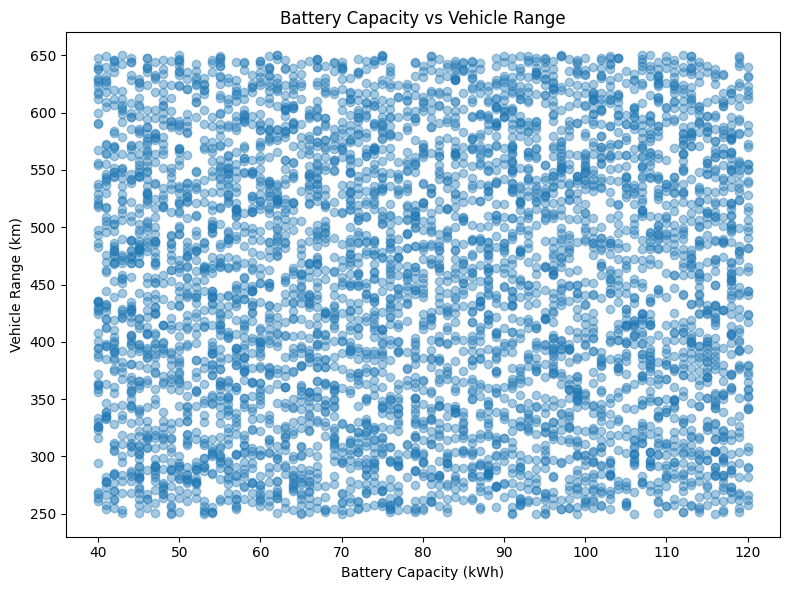

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(clean_df['battery_capacity_kwh'], clean_df['vehicle_range_km'], alpha=0.4)
plt.xlabel('Battery Capacity (kWh)')
plt.ylabel('Vehicle Range (km)')
plt.title('Battery Capacity vs Vehicle Range')
plt.tight_layout()
plt.show()

## 5. Summary KPIs (sanity check against dashboard)

In [15]:
print('Total EV units sold:', clean_df['ev_sales_units'].sum())
print('Countries covered:', clean_df['country'].nunique())
print('Top-selling country:', sales_by_country.idxmax())
print('Average battery capacity (kWh):', round(clean_df['battery_capacity_kwh'].mean(), 2))
print('Average vehicle range (km):', round(clean_df['vehicle_range_km'].mean(), 2))

Total EV units sold: 2251958870
Countries covered: 10
Top-selling country: Canada
Average battery capacity (kWh): 79.75
Average vehicle range (km): 450.28
